# MSCS 634 Lab 6: Association Rule Mining with Apriori and FP-Growth

**Name:** Bikram Lamsal  
**Course Title:** MSCS 634 - Advanced Big Data and Data Mining  
**Lab Assignment Title:** Lab 6 - Association Rule Mining Using Apriori and FP-Growth

## Step 1: Data Preparation

This lab uses the public Groceries transactional dataset, a market-basket dataset commonly used with the R `arules` package. Each row represents one customer transaction and contains a comma-separated list of purchased grocery items. This format is appropriate for association rule mining because the goal is to discover which items occur together inside the same transaction.

The raw transaction rows are converted into two useful formats: a long transaction-item table for exploration and a one-hot encoded basket matrix for Apriori and FP-Growth. The one-hot matrix is required because these algorithms need to know whether each item is present or absent in each transaction.

In [1]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

Matplotlib is building the font cache; this may take a moment.


In [2]:
data_path = Path("data/groceries.csv")

transactions = []
with data_path.open("r", encoding="utf-8") as file:
    for line in file:
        items = sorted(set(item.strip() for item in line.strip().split(",") if item.strip()))
        if items:
            transactions.append(items)

transaction_records = [
    {"transaction_id": transaction_id, "item": item}
    for transaction_id, items in enumerate(transactions, start=1)
    for item in items
]

transactions_df = pd.DataFrame(transaction_records)
transaction_lengths = pd.Series([len(items) for items in transactions], name="items_per_transaction")

print(f"Transactions: {len(transactions):,}")
print(f"Unique items: {transactions_df['item'].nunique():,}")
transactions_df.head()

Transactions: 9,835
Unique items: 169


,transaction_id,item
0,1,citrus fruit
1,1,margarine
2,1,ready soups
3,1,semi-finished bread
4,2,coffee


In [3]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43367 entries, 0 to 43366
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaction_id  43367 non-null  int64 
 1   item            43367 non-null  object
dtypes: int64(1), object(1)
memory usage: 677.7+ KB


In [4]:
transaction_lengths.describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
items_per_transaction,9835.0,4.409456,3.589385,1.0,2.0,3.0,6.0,32.0


In [5]:
top_items = (
    transactions_df["item"]
    .value_counts()
    .head(15)
    .rename_axis("item")
    .reset_index(name="count")
)
top_items

,item,count
0,whole milk,2513
1,other vegetables,1903
2,rolls/buns,1809
3,soda,1715
4,yogurt,1372
5,bottled water,1087
6,root vegetables,1072
7,tropical fruit,1032
8,shopping bags,969
9,sausage,924


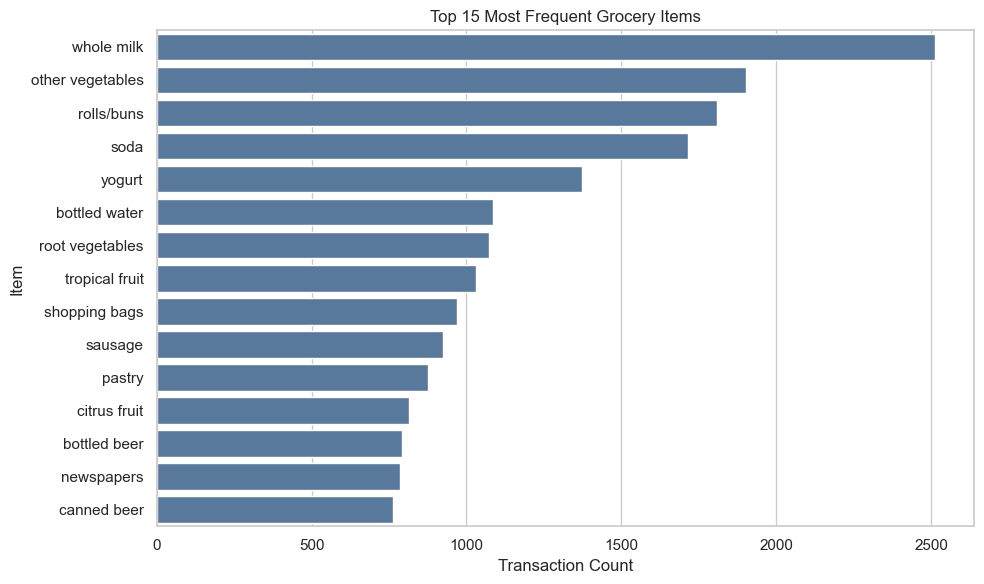

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_items, y="item", x="count", ax=ax, color="#4C78A8")
ax.set_title("Top 15 Most Frequent Grocery Items")
ax.set_xlabel("Transaction Count")
ax.set_ylabel("Item")
plt.tight_layout()
plt.show()

In [7]:
encoder = TransactionEncoder()
encoded_array = encoder.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(encoded_array, columns=encoder.columns_)

print(f"One-hot encoded basket shape: {basket_df.shape}")
basket_df.head()

One-hot encoded basket shape: (9835, 169)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


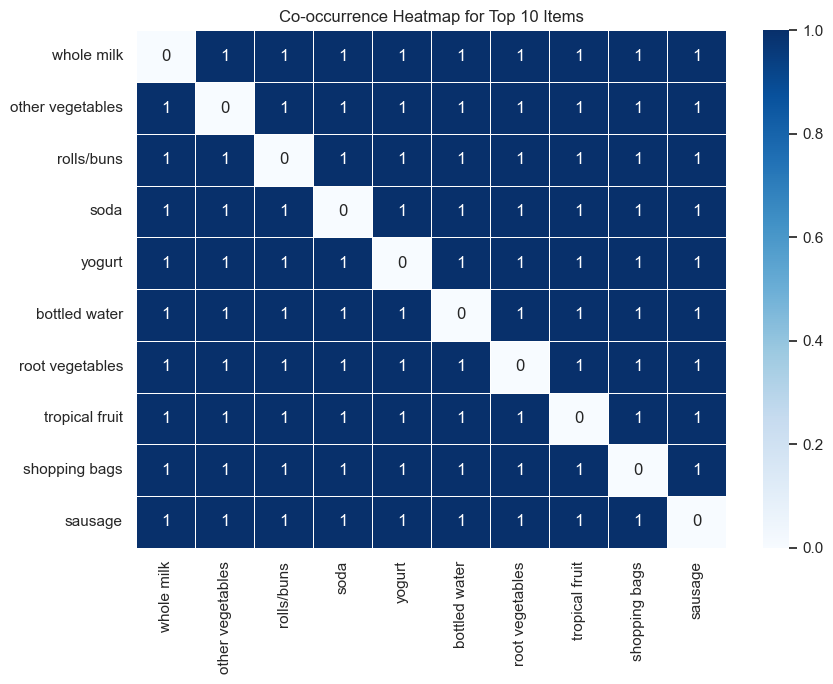

In [8]:
top_10_items = top_items["item"].head(10).tolist()
cooccurrence = basket_df[top_10_items].T.dot(basket_df[top_10_items]).astype(int)
np.fill_diagonal(cooccurrence.values, 0)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cooccurrence, cmap="Blues", annot=True, fmt="d", linewidths=0.5, ax=ax)
ax.set_title("Co-occurrence Heatmap for Top 10 Items")
plt.tight_layout()
plt.show()

### Data Preparation Interpretation

The cleaned dataset contains 9,835 transactions and 169 unique grocery items. Each row in the original file is already a transaction, so the main cleaning steps are trimming item names, removing empty values, and removing duplicate items within the same transaction. These steps are important because inconsistent item names or duplicated items could distort support counts and produce misleading rules.

The item-frequency barplot shows that staples such as `whole milk`, `other vegetables`, `rolls/buns`, `soda`, and `yogurt` appear most often. This matters because frequent single items often become part of frequent itemsets and association rules. The co-occurrence heatmap shows that high-frequency items also tend to appear together, especially combinations involving `whole milk` and `other vegetables`. This early visualization gives a preview of the patterns later confirmed by Apriori, FP-Growth, and association rules.

## Step 2: Frequent Itemset Mining Using Apriori

Apriori is applied with a minimum support threshold of 0.02. This means an itemset must appear in at least 2% of all transactions to be considered frequent. The threshold is high enough to avoid generating thousands of rare itemsets, but low enough to preserve meaningful multi-item grocery combinations.

Apriori works by using the principle that every subset of a frequent itemset must also be frequent. This allows the algorithm to prune unlikely combinations and focus only on itemsets that can meet the support requirement.

In [9]:
MIN_SUPPORT = 0.02
MIN_CONFIDENCE = 0.30

start_time = time.perf_counter()
apriori_itemsets = apriori(basket_df, min_support=MIN_SUPPORT, use_colnames=True)
apriori_runtime = time.perf_counter() - start_time

apriori_itemsets = apriori_itemsets.sort_values("support", ascending=False).reset_index(drop=True)
apriori_itemsets["itemset_length"] = apriori_itemsets["itemsets"].apply(len)
apriori_itemsets["itemset_label"] = apriori_itemsets["itemsets"].apply(lambda itemset: ", ".join(sorted(itemset)))

print(f"Apriori frequent itemsets: {len(apriori_itemsets)}")
print(f"Apriori runtime: {apriori_runtime:.4f} seconds")
apriori_itemsets.head(15)[["itemset_label", "itemset_length", "support"]]

Apriori frequent itemsets: 122
Apriori runtime: 0.0455 seconds


,itemset_label,itemset_length,support
0,whole milk,1,0.255516
1,other vegetables,1,0.193493
2,rolls/buns,1,0.183935
3,soda,1,0.174377
4,yogurt,1,0.139502
5,bottled water,1,0.110524
6,root vegetables,1,0.108998
7,tropical fruit,1,0.104931
8,shopping bags,1,0.098526
9,sausage,1,0.093950


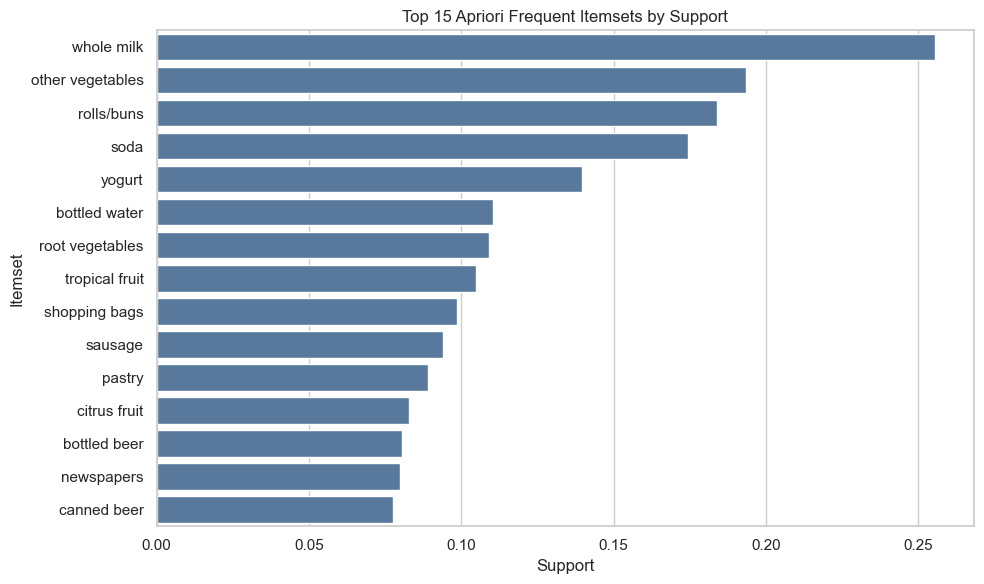

In [10]:
top_apriori_itemsets = apriori_itemsets.head(15).copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_apriori_itemsets, y="itemset_label", x="support", ax=ax, color="#4C78A8")
ax.set_title("Top 15 Apriori Frequent Itemsets by Support")
ax.set_xlabel("Support")
ax.set_ylabel("Itemset")
plt.tight_layout()
plt.show()

### Apriori Interpretation

Apriori identified 122 frequent itemsets at the 2% support threshold. The highest-support itemsets are mostly single high-demand grocery staples, but important multi-item patterns also appear, such as `other vegetables, whole milk` and `rolls/buns, whole milk`. These itemsets indicate product combinations that occur frequently enough to be useful for market-basket analysis.

The outcome shows that the dataset contains both broad purchasing trends and smaller basket patterns. Single items explain which products are generally popular, while multi-itemsets reveal combinations that customers buy together. Those combinations are the foundation for generating association rules in the next step.

## Step 3: Frequent Itemset Mining Using FP-Growth

FP-Growth is applied with the same minimum support threshold so its output can be compared directly with Apriori. Using the same threshold is important because different thresholds would change the number of frequent itemsets and make the algorithms harder to compare fairly.

Unlike Apriori, FP-Growth compresses transactions into a frequent-pattern tree and mines patterns from that structure. This often reduces repeated database scans and can be faster for larger or denser transaction datasets.

In [11]:
start_time = time.perf_counter()
fpgrowth_itemsets = fpgrowth(basket_df, min_support=MIN_SUPPORT, use_colnames=True)
fpgrowth_runtime = time.perf_counter() - start_time

fpgrowth_itemsets = fpgrowth_itemsets.sort_values("support", ascending=False).reset_index(drop=True)
fpgrowth_itemsets["itemset_length"] = fpgrowth_itemsets["itemsets"].apply(len)
fpgrowth_itemsets["itemset_label"] = fpgrowth_itemsets["itemsets"].apply(lambda itemset: ", ".join(sorted(itemset)))

print(f"FP-Growth frequent itemsets: {len(fpgrowth_itemsets)}")
print(f"FP-Growth runtime: {fpgrowth_runtime:.4f} seconds")
fpgrowth_itemsets.head(15)[["itemset_label", "itemset_length", "support"]]

FP-Growth frequent itemsets: 122
FP-Growth runtime: 0.5787 seconds


,itemset_label,itemset_length,support
0,whole milk,1,0.255516
1,other vegetables,1,0.193493
2,rolls/buns,1,0.183935
3,soda,1,0.174377
4,yogurt,1,0.139502
5,bottled water,1,0.110524
6,root vegetables,1,0.108998
7,tropical fruit,1,0.104931
8,shopping bags,1,0.098526
9,sausage,1,0.093950


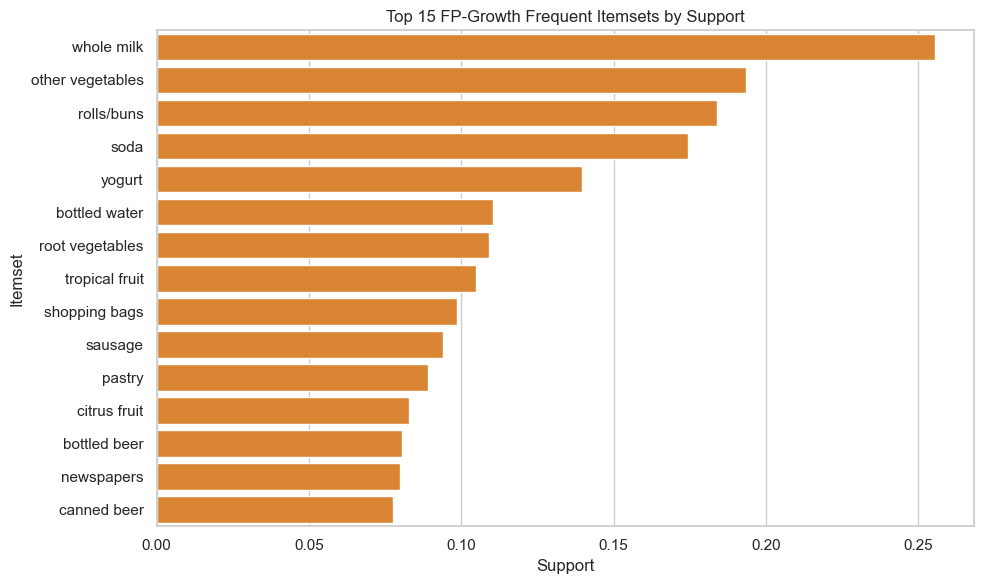

In [12]:
top_fpgrowth_itemsets = fpgrowth_itemsets.head(15).copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_fpgrowth_itemsets, y="itemset_label", x="support", ax=ax, color="#F58518")
ax.set_title("Top 15 FP-Growth Frequent Itemsets by Support")
ax.set_xlabel("Support")
ax.set_ylabel("Itemset")
plt.tight_layout()
plt.show()

In [13]:
apriori_set = set(apriori_itemsets["itemsets"])
fpgrowth_set = set(fpgrowth_itemsets["itemsets"])

algorithm_comparison = pd.DataFrame([
    {
        "algorithm": "Apriori",
        "frequent_itemsets": len(apriori_itemsets),
        "runtime_seconds": apriori_runtime,
    },
    {
        "algorithm": "FP-Growth",
        "frequent_itemsets": len(fpgrowth_itemsets),
        "runtime_seconds": fpgrowth_runtime,
    },
])

print("Itemsets identical:", apriori_set == fpgrowth_set)
algorithm_comparison

Itemsets identical: True


,algorithm,frequent_itemsets,runtime_seconds
0,Apriori,122,0.045513
1,FP-Growth,122,0.578651


### FP-Growth Interpretation

FP-Growth returned the same 122 frequent itemsets as Apriori because both algorithms used the same support threshold on the same one-hot encoded transaction matrix. Matching outputs confirm that both algorithms found the same frequent purchasing patterns. The difference was runtime, not result quality.

In this run, Apriori was faster than FP-Growth. Although FP-Growth is often faster on very large or highly complex transaction data, this moderate dataset and support threshold allowed Apriori to run efficiently. This is an important practical point: the theoretically preferred algorithm is not always faster for every dataset and implementation.

## Step 4: Generating and Analyzing Association Rules

Association rules are generated using a minimum confidence threshold of 0.30. This means the consequent must appear in at least 30% of transactions that contain the antecedent. The threshold filters out weak rules while keeping enough rules for interpretation.

Each rule includes support, confidence, and lift. Support shows how common the entire rule is in the dataset. Confidence shows how often the consequent appears when the antecedent appears. Lift compares that confidence against the baseline popularity of the consequent. Lift greater than 1 indicates that the consequent is more likely when the antecedent appears than it is overall.

In [14]:
apriori_rules = association_rules(apriori_itemsets, metric="confidence", min_threshold=MIN_CONFIDENCE)
fpgrowth_rules = association_rules(fpgrowth_itemsets, metric="confidence", min_threshold=MIN_CONFIDENCE)

for rules_df in [apriori_rules, fpgrowth_rules]:
    rules_df["antecedent_label"] = rules_df["antecedents"].apply(lambda itemset: ", ".join(sorted(itemset)))
    rules_df["consequent_label"] = rules_df["consequents"].apply(lambda itemset: ", ".join(sorted(itemset)))
    rules_df["rule"] = rules_df["antecedent_label"] + " -> " + rules_df["consequent_label"]

apriori_rules = apriori_rules.sort_values(["lift", "confidence"], ascending=False).reset_index(drop=True)
fpgrowth_rules = fpgrowth_rules.sort_values(["lift", "confidence"], ascending=False).reset_index(drop=True)

print(f"Apriori rules: {len(apriori_rules)}")
print(f"FP-Growth rules: {len(fpgrowth_rules)}")
apriori_rules.head(15)[["rule", "support", "confidence", "lift"]]

Apriori rules: 37
FP-Growth rules: 37


,rule,support,confidence,lift
0,"other vegetables, whole milk -> root vegetables",0.023183,0.309783,2.842082
1,"root vegetables, whole milk -> other vegetables",0.023183,0.474012,2.449770
2,root vegetables -> other vegetables,0.047382,0.434701,2.246605
3,whipped/sour cream -> other vegetables,0.028876,0.402837,2.081924
4,"whole milk, yogurt -> other vegetables",0.022267,0.397459,2.054131
5,"other vegetables, yogurt -> whole milk",0.022267,0.512881,2.007235
6,butter -> whole milk,0.027555,0.497248,1.946053
7,pork -> other vegetables,0.021657,0.375661,1.941476
8,curd -> whole milk,0.026131,0.490458,1.919481
9,"other vegetables, root vegetables -> whole milk",0.023183,0.489270,1.914833


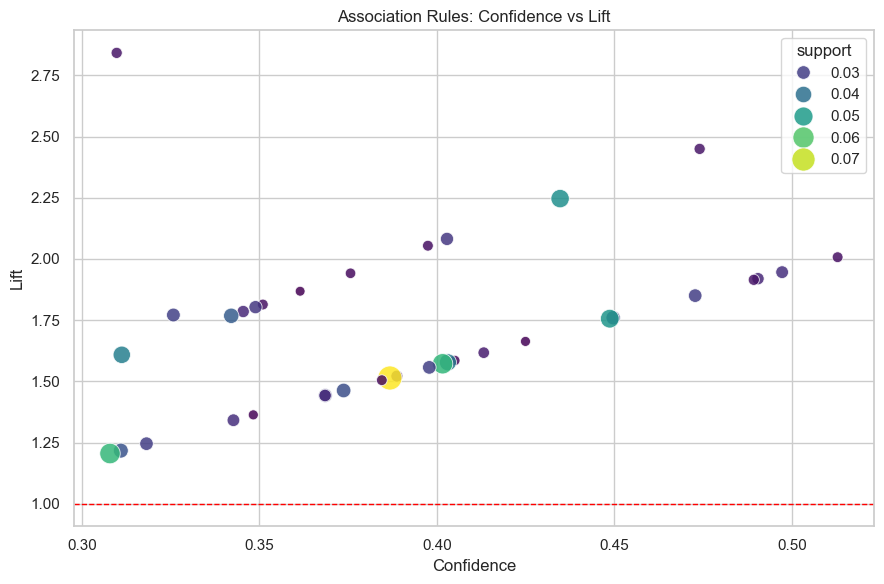

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=apriori_rules,
    x="confidence",
    y="lift",
    size="support",
    hue="support",
    palette="viridis",
    sizes=(50, 300),
    alpha=0.85,
    ax=ax
)
ax.axhline(1, color="red", linestyle="--", linewidth=1)
ax.set_title("Association Rules: Confidence vs Lift")
ax.set_xlabel("Confidence")
ax.set_ylabel("Lift")
plt.tight_layout()
plt.show()

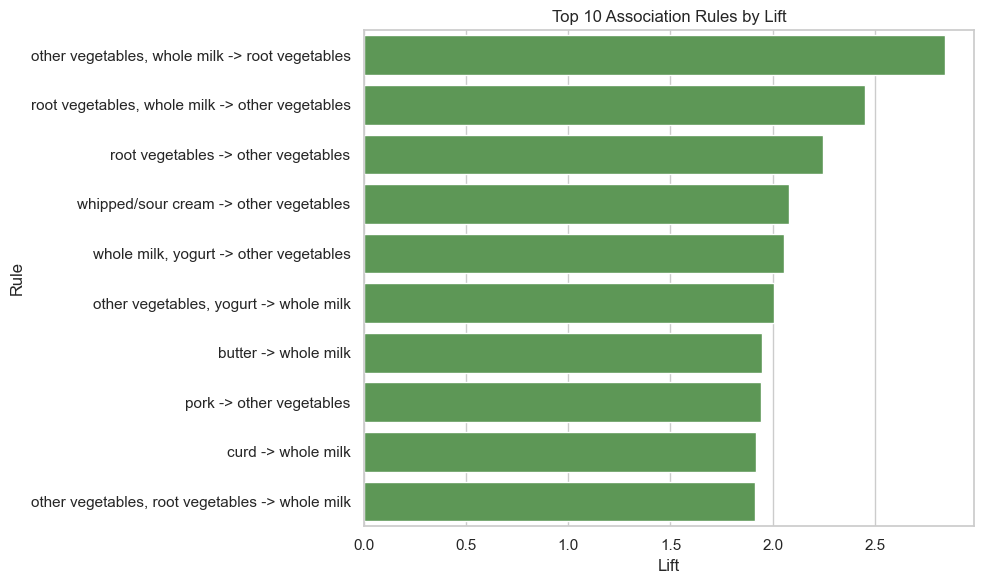

In [16]:
top_rules = apriori_rules.head(10).copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_rules, y="rule", x="lift", ax=ax, color="#54A24B")
ax.set_title("Top 10 Association Rules by Lift")
ax.set_xlabel("Lift")
ax.set_ylabel("Rule")
plt.tight_layout()
plt.show()

### Association Rule Interpretation

The strongest rules are centered around grocery staples. For example, the rule `other vegetables, whole milk -> root vegetables` has high lift, meaning customers who buy both `other vegetables` and `whole milk` are more likely to also buy `root vegetables` than a random customer. Several strong rules also point toward `whole milk` as a consequent, showing that it frequently appears in baskets with items such as `butter`, `curd`, `yogurt`, and `root vegetables`.

The confidence-versus-lift scatter plot helps separate common rules from truly strong associations. A rule can have high confidence simply because the consequent is very popular. Lift adds more context by showing whether the antecedent actually increases the likelihood of the consequent. These rules could support product placement, cross-promotion, coupon bundles, or recommendation decisions. For example, vegetables and dairy staples could be placed or promoted together because they repeatedly appear in related baskets.

## Step 5: Comparative Analysis

This section compares Apriori and FP-Growth outputs, runtime, and rule quality.

In [17]:
rules_comparison = pd.DataFrame([
    {
        "algorithm": "Apriori",
        "frequent_itemsets": len(apriori_itemsets),
        "rules_generated": len(apriori_rules),
        "runtime_seconds": apriori_runtime,
        "max_lift": apriori_rules["lift"].max(),
        "mean_confidence": apriori_rules["confidence"].mean(),
    },
    {
        "algorithm": "FP-Growth",
        "frequent_itemsets": len(fpgrowth_itemsets),
        "rules_generated": len(fpgrowth_rules),
        "runtime_seconds": fpgrowth_runtime,
        "max_lift": fpgrowth_rules["lift"].max(),
        "mean_confidence": fpgrowth_rules["confidence"].mean(),
    },
])
rules_comparison

,algorithm,frequent_itemsets,rules_generated,runtime_seconds,max_lift,mean_confidence
0,Apriori,122,37,0.045513,2.842082,0.391503
1,FP-Growth,122,37,0.578651,2.842082,0.391503


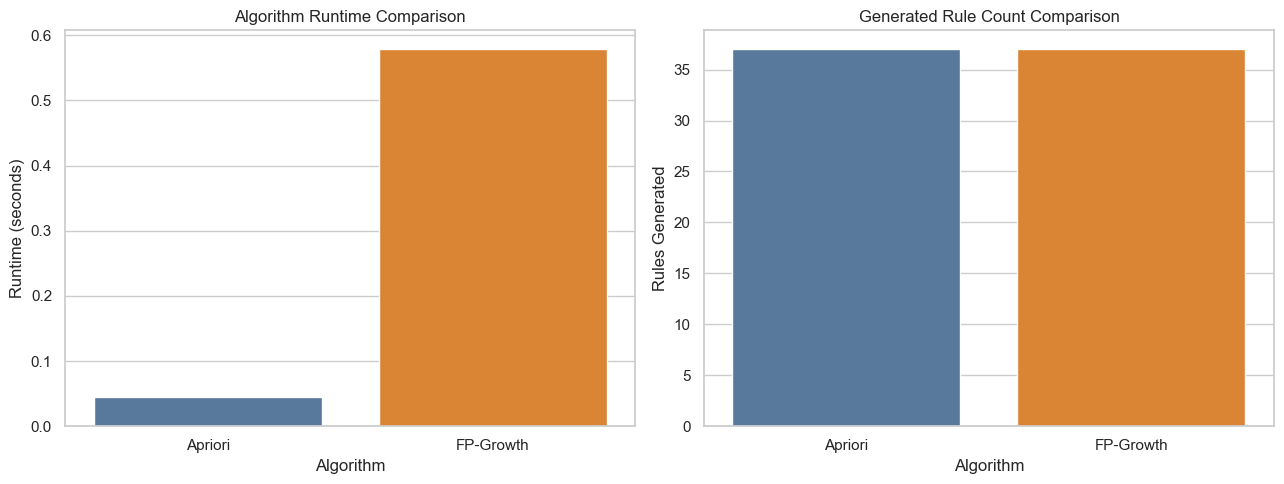

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=rules_comparison, x="algorithm", y="runtime_seconds", ax=axes[0], palette=["#4C78A8", "#F58518"], hue="algorithm", legend=False)
axes[0].set_title("Algorithm Runtime Comparison")
axes[0].set_xlabel("Algorithm")
axes[0].set_ylabel("Runtime (seconds)")

sns.barplot(data=rules_comparison, x="algorithm", y="rules_generated", ax=axes[1], palette=["#4C78A8", "#F58518"], hue="algorithm", legend=False)
axes[1].set_title("Generated Rule Count Comparison")
axes[1].set_xlabel("Algorithm")
axes[1].set_ylabel("Rules Generated")

plt.tight_layout()
plt.show()

### Final Analysis

- Apriori and FP-Growth produced the same frequent itemsets and rules because they used the same transaction matrix, support threshold, and confidence threshold. This confirms that the algorithms agreed on the underlying frequent purchasing patterns.
- Apriori was faster in this run. FP-Growth is often preferred for larger datasets, but this dataset is moderate in size and the chosen support threshold limits the search space enough for Apriori to perform well.
- The most frequent itemsets were dominated by high-demand grocery staples, especially `whole milk`, `other vegetables`, `rolls/buns`, `soda`, and `yogurt`. This outcome is realistic for grocery data because staple products appear repeatedly across many baskets.
- The highest-lift rules were more meaningful than support alone because lift highlights item combinations that occur together more often than expected by chance. This prevents the analysis from focusing only on popular items and helps identify relationships with stronger association value.
- A key challenge was choosing a support threshold. A very low threshold creates too many itemsets and rules, while a high threshold hides useful multi-item patterns. The 0.02 support threshold produced a manageable and interpretable set of results.
- The practical outcome is that association rule mining can support retail decisions such as shelf placement, bundle promotions, and recommendation systems. However, the rules show association, not causation, so business actions should be tested before assuming one item directly causes another purchase.